# **Изучим великий The Boston Housing Dataset**

Выгружаем датасет + библиотеки


In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
import pandas as pd
import numpy as np
import xgboost as xgb
from matplotlib import pyplot as plt
import seaborn as sns

In [32]:
data = pd.read_csv('./BostonHousing.csv')

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [34]:
data.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


Видим, что все данные non-null, обрабатывать их не надо - идем дальше.
Давайте посмотрим на распределния.

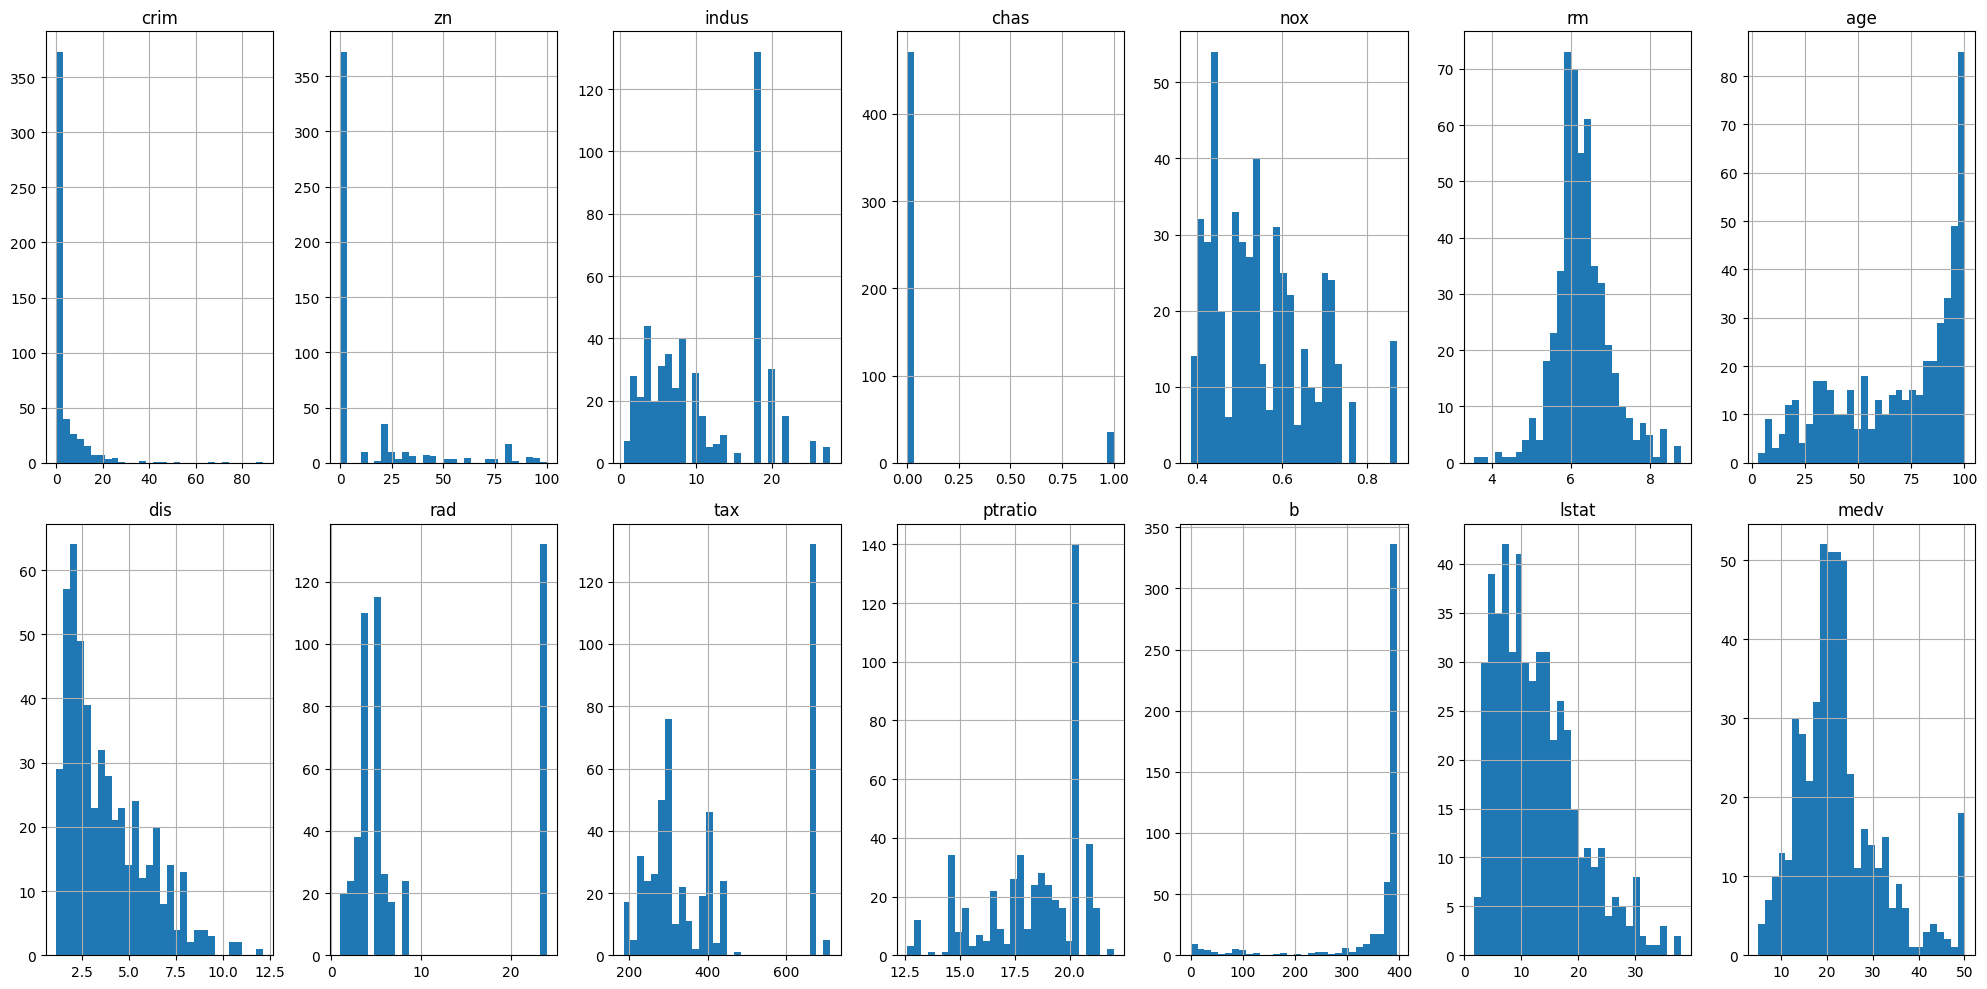

In [35]:
data.hist(figsize=(20, 10), bins=30, layout=(2, 7))
plt.tight_layout()

Видно, что больишнство фич имеет нормальное/биномиальное распределние, хотя crim, zn, b - явно ассиметричны. Также видно выборсы у фичи medv, удалим строки с выбросами.

In [36]:
data = data[data['medv'] < 50]

In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 490 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     490 non-null    float64
 1   zn       490 non-null    float64
 2   indus    490 non-null    float64
 3   chas     490 non-null    int64  
 4   nox      490 non-null    float64
 5   rm       490 non-null    float64
 6   age      490 non-null    float64
 7   dis      490 non-null    float64
 8   rad      490 non-null    int64  
 9   tax      490 non-null    int64  
 10  ptratio  490 non-null    float64
 11  b        490 non-null    float64
 12  lstat    490 non-null    float64
 13  medv     490 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 57.4 KB


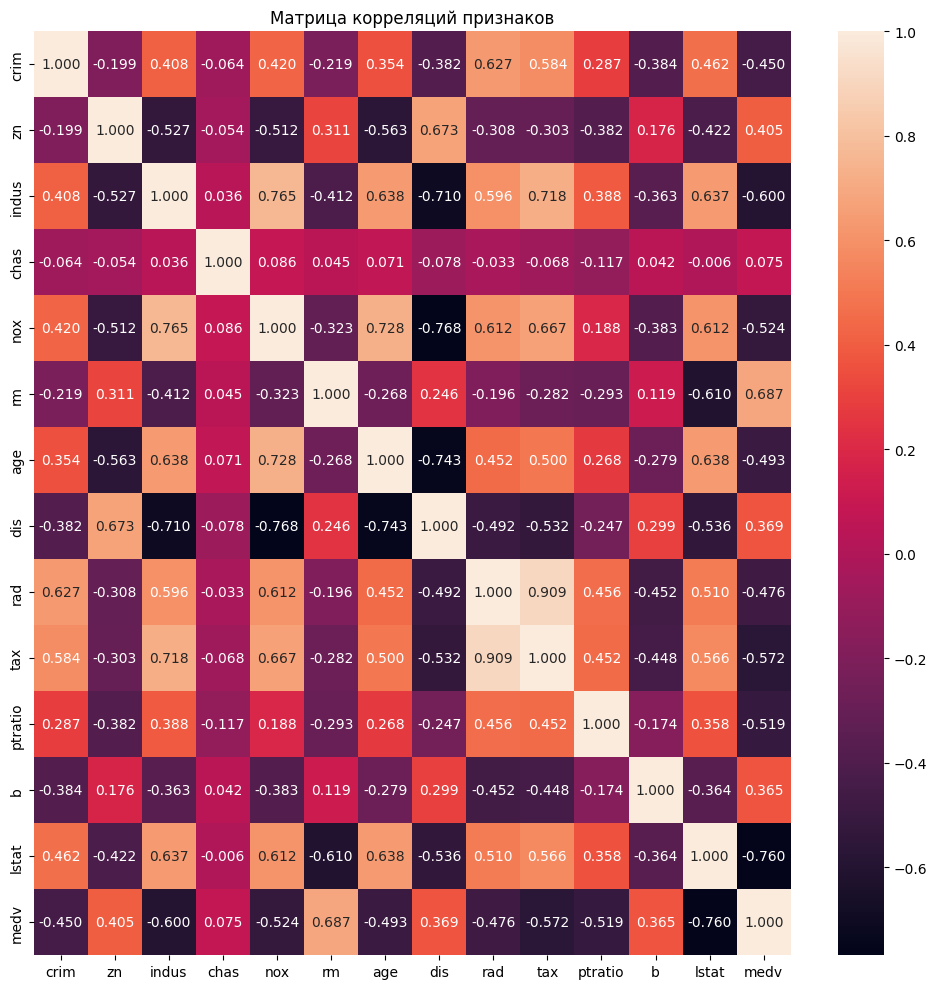

In [38]:
plt.figure(figsize=(10, 10))
sns.heatmap(data.corr(), annot=True, fmt='.3f')
plt.title('Матрица корреляций признаков')
plt.tight_layout()
plt.show()

Из таблицы видно, что каждая фича кроме chas сильно коррелирует с medv, а tax и rad сильно коррелируют между собой

In [39]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [40]:
X = data.drop(columns=['medv'])
y = data['medv']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=72
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [41]:
mse = mean_squared_error(y_test, y_pred)
print(f"MSE={mse:.2f}")

MSE=14.74


In [42]:
num_cols = X.columns

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0, random_state=42))
])

param_grid = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

print("Лучший alpha:", grid_search.best_params_['regressor__alpha'])
best_model = grid_search.best_estimator_

Лучший alpha: 10.0


In [43]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_pred, y_test)
print(f"MSE={mse:.2f}")

MSE=13.67


In [44]:
skewed = ['crim', 'zn', 'b', 'lstat', 'age']
X[skewed] = np.log1p(X[skewed])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=72
)

xgb_model = xgb.XGBRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
print("лучшие параметры", grid_search.best_params_)

y_pred = best_xgb.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"MSE={mse:.2f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
лучшие параметры {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
MSE=6.94
